# Notebook 23 — Resistance-growth Fingerprint Audit

## Goal

This notebook audits whether pure ohmic/contact resistance growth produces a diagnostic fingerprint that can be separated from the SEI-only aging branch established in Notebooks 15–22.

The purpose is not to simulate a full electrochemical aging pathway. Instead, this notebook builds a controlled contrast mechanism:

> contact / ohmic resistance increase without changing lithium inventory, active material, or SEI-state variables.

This branch tests whether resistance-sensitive observables such as Ri(t), pulse voltage drop, and loaded-voltage behavior can serve as primary fitting targets for resistance-growth mechanisms.

## Porsche-oriented relevance

This notebook supports the transition from mechanism simulation to measurement-based aging-model parameterization.

For HV battery aging model development, different mechanisms must not only be simulated; they must be separable from measurement observables. A resistance-growth mechanism should produce a different observable pattern than SEI-only aging.

Expected contrast:

- SEI-only aging: capacity-dominant, voltage-secondary, derivative auxiliary.
- Ohmic/contact resistance growth: Ri(t)-dominant, loaded-voltage shift, weak capacity-state change, relaxation time constants mostly unchanged.

## Mechanism Fingerprint Registry v0.2

All mechanism branches from Notebook 23 onward will use the same fingerprint registry.

Columns:

- `capacity_RPT`
- `Ri_0.05s`
- `Ri_0.1s`
- `Ri_1s`
- `Ri_10s`
- `Ri_recovery_0.1s`
- `Ri_recovery_1s`
- `tau_FG_eff`
- `t95`
- `t99`
- `tau_tail`
- `recovery_amplitude`
- `recovery_area`
- `C25_central_VQ`
- `GITT_finite_rest`
- `ICA_DVA_central`
- `endpoint_boundary`
- `best_fitting_targets`
- `rejection_flags`

## Study design

Mechanism branch:

- OKane2022 DFN
- contact resistance option enabled
- imposed contact resistance levels:
  - 0 mΩ
  - 2 mΩ
  - 5 mΩ
  - 10 mΩ

Diagnostic branches in this notebook:

1. HPPC-like pulse branch at approximately 50% SOC:
   - discharge from full state toward mid-SOC,
   - rest,
   - 1C 10 s discharge pulse,
   - 600 s relaxation.

2. Capacity RPT branch:
   - C/3 discharge to 2.5 V,
   - 60 min rest.

Initial focus:

- Ri(t) / multi-window Ri,
- recovery-side Ri,
- relaxation descriptors,
- capacity RPT,
- resistance-growth fingerprint classification.

C/25 V(Q), GITT, ICA/DVA can be added later only if the Ri/RPT fingerprint does not already separate this mechanism cleanly.

## Interpretation boundary

This is a controlled perturbation branch, not a calendar/cycle aging simulation.

A contact resistance increase modifies terminal voltage under current, but it should not directly change internal lithium inventory or active material. Therefore, capacity loss under voltage cutoff may appear as usable-capacity reduction, not necessarily true electrochemical capacity loss.

The main expected primary fitting target is:

> Ri(t) / pulse voltage response

not capacity fade.

In [1]:
# Cell 1 — Imports, paths, and environment check（导入依赖、路径与环境检查）

from pathlib import Path
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pybamm

warnings.filterwarnings("ignore", category=UserWarning)

REPO = Path("/Users/louislu/projects/pybamm-aging-bridge")
DATA = REPO / "data"
FIGURES = REPO / "figures"
DOC_FIGURES = REPO / "docs" / "figures"
DOC_TABLES = REPO / "docs" / "tables"

for p in [DATA, FIGURES, DOC_FIGURES, DOC_TABLES]:
    p.mkdir(parents=True, exist_ok=True)

print("[ENV] PyBaMM:", pybamm.__version__)
print("[ENV] Repository:", REPO)
print("[ENV] Data dir:", DATA)
print("[ENV] Figures dir:", FIGURES)

assert pybamm.__version__ == "26.3.1", "Expected PyBaMM 26.3.1 for this project."
assert REPO.exists(), f"Repository path does not exist: {REPO}"

print("[OK] Environment check passed.")

[ENV] PyBaMM: 26.3.1
[ENV] Repository: /Users/louislu/projects/pybamm-aging-bridge
[ENV] Data dir: /Users/louislu/projects/pybamm-aging-bridge/data
[ENV] Figures dir: /Users/louislu/projects/pybamm-aging-bridge/figures
[OK] Environment check passed.


In [2]:
# Cell 2 — Mechanism Fingerprint Registry v0.2 contract（机制指纹注册表 v0.2 合同）

FINGERPRINT_REGISTRY_V02 = [
    {
        "metric_layer": "capacity_RPT",
        "description": "External discharge capacity / capacity fade from controlled RPT branch",
        "primary_use": "primary fitting target for capacity-loss mechanisms",
        "risk": "voltage cutoff can mix true capacity loss with usable-capacity boundary shift",
    },
    {
        "metric_layer": "Ri_0.05s",
        "description": "Pulse-on resistance at 50 ms",
        "primary_use": "ohmic / very-fast polarization target",
        "risk": "trigger and sampling-window sensitive",
    },
    {
        "metric_layer": "Ri_0.1s",
        "description": "Pulse-on resistance at 100 ms",
        "primary_use": "ohmic / fast polarization target",
        "risk": "still partly sensitive to pulse detection and sampling",
    },
    {
        "metric_layer": "Ri_1s",
        "description": "Pulse-on resistance at 1 s",
        "primary_use": "fast-to-medium polarization response",
        "risk": "already includes non-ohmic transient contribution",
    },
    {
        "metric_layer": "Ri_10s",
        "description": "Pulse-on resistance near pulse end at 10 s",
        "primary_use": "slow polarization / diffusion-sensitive resistance",
        "risk": "strongly time-window dependent",
    },
    {
        "metric_layer": "Ri_recovery_0.1s",
        "description": "Pulse-off recovery resistance at 100 ms after current interruption",
        "primary_use": "current-off ohmic / fast recovery descriptor",
        "risk": "sensitive to pulse-off timing",
    },
    {
        "metric_layer": "Ri_recovery_1s",
        "description": "Pulse-off recovery resistance at 1 s after current interruption",
        "primary_use": "short recovery descriptor",
        "risk": "mixes ohmic and early relaxation response",
    },
    {
        "metric_layer": "tau_FG_eff",
        "description": "Effective 63.2% voltage-recovery time after pulse-off",
        "primary_use": "secondary relaxation descriptor",
        "risk": "depends on U_inf and relaxation window",
    },
    {
        "metric_layer": "t95",
        "description": "Time to reach 95% of finite-window recovery amplitude",
        "primary_use": "relaxation completion descriptor",
        "risk": "sensitive to final-voltage definition",
    },
    {
        "metric_layer": "t99",
        "description": "Time to reach 99% of finite-window recovery amplitude",
        "primary_use": "slow-tail recovery descriptor",
        "risk": "sensitive to numerical floor and U_inf drift",
    },
    {
        "metric_layer": "tau_tail",
        "description": "Approximate tail time constant from late relaxation residual",
        "primary_use": "slow relaxation audit",
        "risk": "fit-window and residual-floor sensitive",
    },
    {
        "metric_layer": "recovery_amplitude",
        "description": "Finite-window voltage recovery amplitude after pulse-off",
        "primary_use": "secondary relaxation / polarization descriptor",
        "risk": "depends on pulse depth and final rest duration",
    },
    {
        "metric_layer": "recovery_area",
        "description": "Integral of voltage recovery path over the relaxation window",
        "primary_use": "aggregate relaxation-energy-like descriptor",
        "risk": "depends on rest duration and U_inf definition",
    },
    {
        "metric_layer": "C25_central_VQ",
        "description": "C/25 central-window V(Q) drift after endpoint control",
        "primary_use": "secondary voltage-shape constraint",
        "risk": "protocol-sensitive; endpoint must be excluded",
    },
    {
        "metric_layer": "GITT_finite_rest",
        "description": "Finite-rest OCV-like voltage points from pulse-rest protocol",
        "primary_use": "secondary quasi-equilibrium voltage-shape target",
        "risk": "finite rest is not strict thermodynamic OCV",
    },
    {
        "metric_layer": "ICA_DVA_central",
        "description": "Central-window derivative voltage features",
        "primary_use": "auxiliary audit descriptor unless smoothing-stable",
        "risk": "smoothing and curvature sensitive",
    },
    {
        "metric_layer": "endpoint_boundary",
        "description": "Endpoint / cutoff boundary behavior",
        "primary_use": "boundary diagnostic only",
        "risk": "cutoff-boundary amplification and usable-capacity shifts",
    },
    {
        "metric_layer": "best_fitting_targets",
        "description": "Ranked target hierarchy for parameterization",
        "primary_use": "model calibration design",
        "risk": "must respect feature qualification rules",
    },
    {
        "metric_layer": "rejection_flags",
        "description": "Flags from aging-evidence rejection rules",
        "primary_use": "prevent artifact-driven fitting",
        "risk": "none; mandatory audit layer",
    },
]

fingerprint_registry_v02 = pd.DataFrame(FINGERPRINT_REGISTRY_V02)

registry_path = DATA / "mechanism_fingerprint_registry_v0_2.csv"
fingerprint_registry_v02.to_csv(registry_path, index=False)

print(f"[OK] saved: {registry_path}")
display(fingerprint_registry_v02)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/mechanism_fingerprint_registry_v0_2.csv


,metric_layer,description,primary_use,risk
0,capacity_RPT,External discharge capacity / capacity fade fr...,primary fitting target for capacity-loss mecha...,voltage cutoff can mix true capacity loss with...
1,Ri_0.05s,Pulse-on resistance at 50 ms,ohmic / very-fast polarization target,trigger and sampling-window sensitive
2,Ri_0.1s,Pulse-on resistance at 100 ms,ohmic / fast polarization target,still partly sensitive to pulse detection and ...
3,Ri_1s,Pulse-on resistance at 1 s,fast-to-medium polarization response,already includes non-ohmic transient contribution
4,Ri_10s,Pulse-on resistance near pulse end at 10 s,slow polarization / diffusion-sensitive resist...,strongly time-window dependent
5,Ri_recovery_0.1s,Pulse-off recovery resistance at 100 ms after ...,current-off ohmic / fast recovery descriptor,sensitive to pulse-off timing
6,Ri_recovery_1s,Pulse-off recovery resistance at 1 s after cur...,short recovery descriptor,mixes ohmic and early relaxation response
7,tau_FG_eff,Effective 63.2% voltage-recovery time after pu...,secondary relaxation descriptor,depends on U_inf and relaxation window
8,t95,Time to reach 95% of finite-window recovery am...,relaxation completion descriptor,sensitive to final-voltage definition
9,t99,Time to reach 99% of finite-window recovery am...,slow-tail recovery descriptor,sensitive to numerical floor and U_inf drift


## Methodological boundary before resistance-growth execution

This notebook treats contact resistance as a controlled mechanism contrast.

Expected physical behavior:

- pulse-on voltage drop should increase nearly proportionally to imposed contact resistance;
- Ri(t) should show an approximately window-invariant additive increase for short and long pulse windows;
- relaxation descriptors such as tau_FG_eff, t95, t99, and tau_tail should remain mostly unchanged if the perturbation is purely ohmic;
- finite-rest voltage after current interruption should be much less affected than loaded voltage;
- capacity RPT may show apparent usable-capacity reduction due to earlier 2.5 V terminal-voltage cutoff, but this is not equivalent to loss of lithium inventory.

The main question is whether this fingerprint is separable from SEI-only aging.

In [4]:
# Cell 3 — OKane2022 model builder with contact resistance（带接触电阻选项的 OKane2022 模型构建）

CONTACT_R_LEVELS_OHM = {
    "Rcontact_0mOhm": 0.000,
    "Rcontact_2mOhm": 0.002,
    "Rcontact_5mOhm": 0.005,
    "Rcontact_10mOhm": 0.010,
}


def build_contact_resistance_model(contact_resistance_ohm):
    """
    Build DFN model with contact resistance enabled.

    This is a controlled ohmic/contact resistance perturbation branch.
    Degradation mechanisms are disabled.
    """
    options = {
        "contact resistance": "true",
        "SEI": "none",
        "lithium plating": "none",
        "loss of active material": "none",
        "particle mechanics": "none",
        "thermal": "isothermal",
    }

    model = pybamm.lithium_ion.DFN(options=options)
    parameter_values = pybamm.ParameterValues("OKane2022")

    # PyBaMM parameter name used by contact-resistance option.
    parameter_values.update(
        {"Contact resistance [Ohm]": contact_resistance_ohm},
        check_already_exists=False,
    )

    return model, parameter_values


def make_solver():
    """Create a conservative CasADi solver for DFN diagnostic runs."""
    return pybamm.CasadiSolver(
        mode="safe",
        atol=1e-6,
        rtol=1e-6,
        dt_max=600,
    )


# Smoke test
for label, r_ohm in CONTACT_R_LEVELS_OHM.items():
    model, pv = build_contact_resistance_model(r_ohm)
    print(f"[OK] model built: {label} | R_contact={r_ohm*1000:.1f} mΩ | model={model.name}")

print("[OK] Contact-resistance model builder smoke test passed.")

[OK] model built: Rcontact_0mOhm | R_contact=0.0 mΩ | model=Doyle-Fuller-Newman model
[OK] model built: Rcontact_2mOhm | R_contact=2.0 mΩ | model=Doyle-Fuller-Newman model
[OK] model built: Rcontact_5mOhm | R_contact=5.0 mΩ | model=Doyle-Fuller-Newman model
[OK] model built: Rcontact_10mOhm | R_contact=10.0 mΩ | model=Doyle-Fuller-Newman model
[OK] Contact-resistance model builder smoke test passed.


In [5]:
# Cell 4 — Diagnostic protocol constants for resistance-growth fingerprint（阻抗增长指纹诊断协议常数）

# HPPC-like mid-SOC pulse branch
HPPC_PRE_DISCHARGE_STEP = "Discharge at C/3 for 90 minutes"
HPPC_REST_BEFORE_PULSE = "Rest for 60 minutes"
HPPC_PULSE_STEP = "Discharge at 1C for 10 seconds"
HPPC_REST_AFTER_PULSE = "Rest for 600 seconds"
HPPC_PERIOD = "0.1 seconds"

HPPC_STEPS = [
    HPPC_PRE_DISCHARGE_STEP,
    HPPC_REST_BEFORE_PULSE,
    HPPC_PULSE_STEP,
    HPPC_REST_AFTER_PULSE,
]

# Capacity RPT branch
CAPACITY_RPT_STEPS = [
    "Discharge at C/3 until 2.5 V",
    "Rest for 60 minutes",
]
CAPACITY_RPT_PERIOD = "60 seconds"

# Current thresholds for OKane2022 5 Ah cell:
# C/3 ≈ 1.67 A; 1C ≈ 5 A
HPPC_PULSE_CURRENT_LO_A = 4.5
HPPC_PULSE_CURRENT_HI_A = 5.5
HPPC_PULSE_DURATION_LO_S = 8.0
HPPC_PULSE_DURATION_HI_S = 12.0

CAPACITY_CURRENT_LO_A = 1.4
CAPACITY_CURRENT_HI_A = 1.9
CAPACITY_DURATION_LO_MIN = 150
CAPACITY_DURATION_HI_MIN = 230

RI_TIME_WINDOWS_S = [0.05, 0.1, 1.0, 10.0]
RECOVERY_RI_WINDOWS_S = [0.1, 1.0]

print("[CONFIG] contact resistance levels:", CONTACT_R_LEVELS_OHM)
print("[CONFIG] HPPC steps:")
for step in HPPC_STEPS:
    print("  -", step)
print("[CONFIG] capacity RPT steps:")
for step in CAPACITY_RPT_STEPS:
    print("  -", step)

print("[OK] Protocol constants defined.")

[CONFIG] contact resistance levels: {'Rcontact_0mOhm': 0.0, 'Rcontact_2mOhm': 0.002, 'Rcontact_5mOhm': 0.005, 'Rcontact_10mOhm': 0.01}
[CONFIG] HPPC steps:
  - Discharge at C/3 for 90 minutes
  - Rest for 60 minutes
  - Discharge at 1C for 10 seconds
  - Rest for 600 seconds
[CONFIG] capacity RPT steps:
  - Discharge at C/3 until 2.5 V
  - Rest for 60 minutes
[OK] Protocol constants defined.


In [6]:
# Cell 5 — Run HPPC-like and capacity RPT branches（运行 HPPC-like 与容量 RPT 诊断分支）

def run_experiment_for_contact_branch(label, contact_resistance_ohm, experiment_steps, period, initial_soc=1.0):
    model, pv = build_contact_resistance_model(contact_resistance_ohm)
    experiment = pybamm.Experiment(experiment_steps, period=period)

    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        experiment=experiment,
        solver=make_solver(),
    )

    print(f"[RUN] {label} | R_contact={contact_resistance_ohm*1000:.1f} mΩ | steps={len(experiment_steps)}")
    sol = sim.solve(initial_soc=initial_soc)
    print(f"[OK] solved: {label}")

    return sol


hppc_solutions = {}
capacity_solutions = {}

for label, r_ohm in CONTACT_R_LEVELS_OHM.items():
    hppc_solutions[label] = run_experiment_for_contact_branch(
        label=label,
        contact_resistance_ohm=r_ohm,
        experiment_steps=HPPC_STEPS,
        period=HPPC_PERIOD,
        initial_soc=1.0,
    )

for label, r_ohm in CONTACT_R_LEVELS_OHM.items():
    capacity_solutions[label] = run_experiment_for_contact_branch(
        label=label,
        contact_resistance_ohm=r_ohm,
        experiment_steps=CAPACITY_RPT_STEPS,
        period=CAPACITY_RPT_PERIOD,
        initial_soc=1.0,
    )

print("[OK] All contact-resistance diagnostic branches solved.")

[RUN] Rcontact_0mOhm | R_contact=0.0 mΩ | steps=4
[OK] solved: Rcontact_0mOhm
[RUN] Rcontact_2mOhm | R_contact=2.0 mΩ | steps=4
[OK] solved: Rcontact_2mOhm
[RUN] Rcontact_5mOhm | R_contact=5.0 mΩ | steps=4
[OK] solved: Rcontact_5mOhm
[RUN] Rcontact_10mOhm | R_contact=10.0 mΩ | steps=4
[OK] solved: Rcontact_10mOhm
[RUN] Rcontact_0mOhm | R_contact=0.0 mΩ | steps=2
[OK] solved: Rcontact_0mOhm
[RUN] Rcontact_2mOhm | R_contact=2.0 mΩ | steps=2
[OK] solved: Rcontact_2mOhm
[RUN] Rcontact_5mOhm | R_contact=5.0 mΩ | steps=2
[OK] solved: Rcontact_5mOhm
[RUN] Rcontact_10mOhm | R_contact=10.0 mΩ | steps=2
[OK] solved: Rcontact_10mOhm
[OK] All contact-resistance diagnostic branches solved.


In [7]:
# Cell 6 — Current-segment summarizer（电流分段审计工具）

def summarize_current_segments(sol, condition, eps=1e-5):
    """
    Summarize sign-based current segments.

    PyBaMM sign convention:
    +I = discharge
    -I = charge
    near-zero = rest
    """
    t = np.asarray(sol["Time [s]"].entries, dtype=float)
    v = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)
    i = np.asarray(sol["Current [A]"].entries, dtype=float)

    state = np.where(i > eps, "discharge", np.where(i < -eps, "charge", "rest"))
    change_idx = np.r_[0, np.flatnonzero(state[1:] != state[:-1]) + 1, len(state)]

    rows = []
    for k in range(len(change_idx) - 1):
        a, b = change_idx[k], change_idx[k + 1]
        if b - a < 2:
            continue

        rows.append({
            "condition": condition,
            "segment_id": k,
            "segment_type": state[a],
            "idx_start": int(a),
            "idx_stop": int(b),
            "t_start_s": float(t[a]),
            "t_end_s": float(t[b - 1]),
            "duration_s": float(t[b - 1] - t[a]),
            "duration_min": float((t[b - 1] - t[a]) / 60),
            "U_start_V": float(v[a]),
            "U_end_V": float(v[b - 1]),
            "I_mean_A": float(np.mean(i[a:b])),
            "I_min_A": float(np.min(i[a:b])),
            "I_max_A": float(np.max(i[a:b])),
            "n_points": int(b - a),
        })

    return pd.DataFrame(rows)


hppc_segment_tables = []
capacity_segment_tables = []

for label, sol in hppc_solutions.items():
    hppc_segment_tables.append(summarize_current_segments(sol, label))

for label, sol in capacity_solutions.items():
    capacity_segment_tables.append(summarize_current_segments(sol, label))

hppc_segment_audit = pd.concat(hppc_segment_tables, ignore_index=True)
capacity_segment_audit = pd.concat(capacity_segment_tables, ignore_index=True)

hppc_segment_path = DATA / "resistance_growth_hppc_segment_audit.csv"
capacity_segment_path = DATA / "resistance_growth_capacity_segment_audit.csv"

hppc_segment_audit.to_csv(hppc_segment_path, index=False)
capacity_segment_audit.to_csv(capacity_segment_path, index=False)

print(f"[OK] saved: {hppc_segment_path}")
print(f"[OK] saved: {capacity_segment_path}")

display(hppc_segment_audit.groupby(["condition", "segment_type"]).agg(
    n_segments=("segment_id", "count"),
    total_duration_min=("duration_min", "sum"),
    I_mean_mean=("I_mean_A", "mean"),
))

display(capacity_segment_audit.groupby(["condition", "segment_type"]).agg(
    n_segments=("segment_id", "count"),
    total_duration_min=("duration_min", "sum"),
    I_mean_mean=("I_mean_A", "mean"),
))

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/resistance_growth_hppc_segment_audit.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/resistance_growth_capacity_segment_audit.csv


n_segments  total_duration_min  I_mean_mean
condition       segment_type                                             
Rcontact_0mOhm  discharge              2           90.166667     3.333333
                rest                   2           70.000000     0.000000
Rcontact_10mOhm discharge              2           90.166667     3.333333
                rest                   2           70.000000     0.000000
Rcontact_2mOhm  discharge              2           90.166667     3.333333
                rest                   2           70.000000     0.000000
Rcontact_5mOhm  discharge              2           90.166667     3.333333
                rest                   2           70.000000     0.000000

n_segments  total_duration_min  I_mean_mean
condition       segment_type                                             
Rcontact_0mOhm  discharge              1          181.791653     1.666667
                rest                   1           60.000000     0.000000
Rcontact_10mOhm discharge              1          181.653847     1.666667
                rest                   1           60.000000     0.000000
Rcontact_2mOhm  discharge              1          181.763955     1.666667
                rest                   1           60.000000     0.000000
Rcontact_5mOhm  discharge              1          181.722524     1.666667
                rest                   1           60.000000     0.000000

In [9]:
# Cell 7 — HPPC pulse selection and multi-window Ri(t) extraction（HPPC 脉冲选段与多时间窗 Ri(t) 提取）

def value_at_time(t, y, target_t):
    """Nearest-sample value at target time."""
    idx = int(np.argmin(np.abs(t - target_t)))
    return float(y[idx]), float(t[idx])


def trapezoid_integral(y, x):
    """Compatibility wrapper for trapezoidal integration."""
    if hasattr(np, "trapezoid"):
        return np.trapezoid(y, x)
    return np.trapz(y, x)

    
def extract_hppc_resistance_descriptors(sol, condition):
    """
    Extract multi-window Ri(t), recovery-side Ri, and relaxation descriptors
    from the selected 1C 10s discharge pulse.
    """
    seg = hppc_segment_audit[hppc_segment_audit["condition"] == condition].copy()

    pulse_candidates = seg[
        (seg["segment_type"] == "discharge")
        & (seg["I_mean_A"].between(HPPC_PULSE_CURRENT_LO_A, HPPC_PULSE_CURRENT_HI_A))
        & (seg["duration_s"].between(HPPC_PULSE_DURATION_LO_S, HPPC_PULSE_DURATION_HI_S))
    ].sort_values("t_start_s")

    if pulse_candidates.empty:
        raise RuntimeError(f"No valid 1C 10s pulse found for {condition}")

    pulse = pulse_candidates.iloc[-1]

    t = np.asarray(sol["Time [s]"].entries, dtype=float)
    u = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)
    i = np.asarray(sol["Current [A]"].entries, dtype=float)

    t_on = float(pulse["t_start_s"])
    t_off = float(pulse["t_end_s"])

    # Reference before pulse
    U_C, t_C = value_at_time(t, u, t_on - 0.6)
    I_C, _ = value_at_time(t, i, t_on - 0.6)

    # Pulse current reference
    pulse_mask = (t >= t_on + 0.2) & (t <= t_off - 0.2)
    I_pulse = float(np.mean(i[pulse_mask]))

    deltaI_on = I_pulse - I_C

    row = {
        "condition": condition,
        "R_contact_mOhm": CONTACT_R_LEVELS_OHM[condition] * 1000,
        "t_on_s": t_on,
        "t_off_s": t_off,
        "U_C_V": U_C,
        "I_C_A": I_C,
        "I_pulse_A": I_pulse,
        "deltaI_on_A": deltaI_on,
    }

    # Pulse-on Ri(t)
    for w in RI_TIME_WINDOWS_S:
        target = t_on + min(w, t_off - t_on - 0.02)
        U_w, t_w = value_at_time(t, u, target)
        I_w, _ = value_at_time(t, i, target)

        Ri_ohm = (U_C - U_w) / deltaI_on
        row[f"Ri_{w:g}s_mOhm"] = Ri_ohm * 1000
        row[f"U_at_{w:g}s_V"] = U_w
        row[f"t_at_{w:g}s_s"] = t_w

    # Recovery-side Ri
    U_E, t_E = value_at_time(t, u, t_off - 0.02)
    I_E, _ = value_at_time(t, i, t_off - 0.02)

    row["U_E_V"] = U_E
    row["I_E_A"] = I_E

    for w in RECOVERY_RI_WINDOWS_S:
        U_rec, t_rec = value_at_time(t, u, t_off + w)
        I_rec, _ = value_at_time(t, i, t_off + w)

        deltaI_off = I_E - I_rec
        Ri_rec_ohm = (U_rec - U_E) / deltaI_off if abs(deltaI_off) > 1e-12 else np.nan

        row[f"Ri_recovery_{w:g}s_mOhm"] = Ri_rec_ohm * 1000
        row[f"U_recovery_{w:g}s_V"] = U_rec
        row[f"t_recovery_{w:g}s_s"] = t_rec

    # Relaxation descriptors after pulse-off
    rest_mask = (t >= t_off) & (t <= t_off + 600)
    t_rest = t[rest_mask] - t_off
    u_rest = u[rest_mask]

    # U_off at beginning of rest, U_inf from last 60 s of relaxation
    U_off = float(u_rest[0])
    tail_mask = t_rest >= (t_rest.max() - 60)
    U_inf = float(np.mean(u_rest[tail_mask]))

    recovery_amp = U_inf - U_off

    row["U_off_V"] = U_off
    row["U_inf_600s_V"] = U_inf
    row["recovery_amplitude_mV"] = recovery_amp * 1000

    if recovery_amp > 1e-9:
        frac = (u_rest - U_off) / recovery_amp

        def first_time_to_fraction(frac_target):
            idxs = np.flatnonzero(frac >= frac_target)
            return float(t_rest[idxs[0]]) if len(idxs) else np.nan

        row["tau_FG_eff_s"] = first_time_to_fraction(1 - np.exp(-1))
        row["t95_s"] = first_time_to_fraction(0.95)
        row["t99_s"] = first_time_to_fraction(0.99)

        # Recovery area: integrated achieved recovery above U_off
        row["recovery_area_mV_s"] = float(
            trapezoid_integral((u_rest - U_off) * 1000, t_rest)
        )

        # Tail time constant from residual log-slope between 50% and 95%
        residual = U_inf - u_rest
        fit_mask = (
            (frac >= 0.50)
            & (frac <= 0.95)
            & (residual > 1e-8)
        )

        if fit_mask.sum() >= 5:
            x = t_rest[fit_mask]
            y = np.log(residual[fit_mask])
            slope, intercept = np.polyfit(x, y, 1)
            row["tau_tail_s"] = float(-1 / slope) if slope < 0 else np.nan
        else:
            row["tau_tail_s"] = np.nan
    else:
        row["tau_FG_eff_s"] = np.nan
        row["t95_s"] = np.nan
        row["t99_s"] = np.nan
        row["tau_tail_s"] = np.nan
        row["recovery_area_mV_s"] = np.nan

    return row


hppc_descriptor_rows = []

for label, sol in hppc_solutions.items():
    hppc_descriptor_rows.append(
        extract_hppc_resistance_descriptors(sol=sol, condition=label)
    )

hppc_descriptor_table = pd.DataFrame(hppc_descriptor_rows).sort_values("R_contact_mOhm").reset_index(drop=True)

descriptor_path = DATA / "resistance_growth_hppc_descriptor_table.csv"
hppc_descriptor_table.to_csv(descriptor_path, index=False)

print(f"[OK] saved: {descriptor_path}")
display(hppc_descriptor_table[[
    "condition", "R_contact_mOhm",
    "Ri_0.05s_mOhm", "Ri_0.1s_mOhm", "Ri_1s_mOhm", "Ri_10s_mOhm",
    "Ri_recovery_0.1s_mOhm", "Ri_recovery_1s_mOhm",
    "tau_FG_eff_s", "t95_s", "t99_s", "tau_tail_s",
    "recovery_amplitude_mV", "recovery_area_mV_s",
]])

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/resistance_growth_hppc_descriptor_table.csv


,condition,R_contact_mOhm,Ri_0.05s_mOhm,Ri_0.1s_mOhm,Ri_1s_mOhm,Ri_10s_mOhm,Ri_recovery_0.1s_mOhm,Ri_recovery_1s_mOhm,tau_FG_eff_s,t95_s,t99_s,tau_tail_s,recovery_amplitude_mV,recovery_area_mV_s
0,Rcontact_0mOhm,0.0,24.407531,24.491691,25.193035,29.980926,24.093584,24.401713,1.818989e-12,36.5,156.8,29.801303,146.781502,87005.511729
1,Rcontact_2mOhm,2.0,26.407531,26.491691,27.193035,31.980926,26.093584,26.401713,1.818989e-12,33.8,148.7,28.965418,156.781502,93005.511730
2,Rcontact_5mOhm,5.0,29.407531,29.491691,30.193035,34.980926,29.093584,29.401713,1.818989e-12,30.1,138.0,27.777759,171.781502,102005.511729
3,Rcontact_10mOhm,10.0,34.407531,34.491691,35.193035,39.980926,34.093584,34.401713,1.818989e-12,25.0,123.3,26.046840,196.781502,117005.511729


In [10]:
# Cell 7A — Corrected post-ohmic relaxation descriptors（去除瞬时欧姆跳变后的恢复描述符）

RELAX_START_DELAY_S = 0.1

def corrected_post_ohmic_relaxation_descriptors(sol, condition, relax_start_delay_s=RELAX_START_DELAY_S):
    """
    Compute post-ohmic relaxation descriptors by starting the relaxation analysis
    after the immediate current-off voltage jump.

    This avoids interpreting contact-resistance-induced ohmic jump as slow relaxation.
    """
    base_row = hppc_descriptor_table[hppc_descriptor_table["condition"] == condition].iloc[0]
    t_off = float(base_row["t_off_s"])

    t = np.asarray(sol["Time [s]"].entries, dtype=float)
    u = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)

    t_start = t_off + relax_start_delay_s
    t_end = t_off + 600

    rest_mask = (t >= t_start) & (t <= t_end)
    t_rest = t[rest_mask] - t_start
    u_rest = u[rest_mask]

    if len(t_rest) < 20:
        raise RuntimeError(f"Too few corrected relaxation points for {condition}")

    U_start = float(u_rest[0])

    tail_mask = t_rest >= (t_rest.max() - 60)
    U_inf = float(np.mean(u_rest[tail_mask]))

    amp = U_inf - U_start

    row = {
        "condition": condition,
        "R_contact_mOhm": CONTACT_R_LEVELS_OHM[condition] * 1000,
        "relax_start_delay_s": relax_start_delay_s,
        "U_relax_start_V": U_start,
        "U_inf_600s_V": U_inf,
        "post_ohmic_recovery_amplitude_mV": amp * 1000,
    }

    if amp > 1e-9:
        frac = (u_rest - U_start) / amp

        def first_time_to_fraction(frac_target):
            idxs = np.flatnonzero(frac >= frac_target)
            return float(t_rest[idxs[0]]) if len(idxs) else np.nan

        row["post_ohmic_tau_FG_eff_s"] = first_time_to_fraction(1 - np.exp(-1))
        row["post_ohmic_t95_s"] = first_time_to_fraction(0.95)
        row["post_ohmic_t99_s"] = first_time_to_fraction(0.99)

        row["post_ohmic_recovery_area_mV_s"] = float(
            trapezoid_integral((u_rest - U_start) * 1000, t_rest)
        )

        residual = U_inf - u_rest
        fit_mask = (
            (frac >= 0.50)
            & (frac <= 0.95)
            & (residual > 1e-8)
        )

        if fit_mask.sum() >= 5:
            x = t_rest[fit_mask]
            y = np.log(residual[fit_mask])
            slope, intercept = np.polyfit(x, y, 1)
            row["post_ohmic_tau_tail_s"] = float(-1 / slope) if slope < 0 else np.nan
        else:
            row["post_ohmic_tau_tail_s"] = np.nan
    else:
        row["post_ohmic_tau_FG_eff_s"] = np.nan
        row["post_ohmic_t95_s"] = np.nan
        row["post_ohmic_t99_s"] = np.nan
        row["post_ohmic_tau_tail_s"] = np.nan
        row["post_ohmic_recovery_area_mV_s"] = np.nan

    return row


corrected_relax_rows = []

for label, sol in hppc_solutions.items():
    corrected_relax_rows.append(
        corrected_post_ohmic_relaxation_descriptors(sol=sol, condition=label)
    )

corrected_relaxation_table = (
    pd.DataFrame(corrected_relax_rows)
    .sort_values("R_contact_mOhm")
    .reset_index(drop=True)
)

corrected_relax_path = DATA / "resistance_growth_corrected_relaxation_descriptor_table.csv"
corrected_relaxation_table.to_csv(corrected_relax_path, index=False)

print(f"[OK] saved: {corrected_relax_path}")
display(corrected_relaxation_table)

# Compare raw vs corrected relaxation amplitudes and times
relax_comparison = hppc_descriptor_table[[
    "condition", "R_contact_mOhm",
    "recovery_amplitude_mV",
    "tau_FG_eff_s", "t95_s", "t99_s", "tau_tail_s",
    "recovery_area_mV_s"
]].merge(
    corrected_relaxation_table,
    on=["condition", "R_contact_mOhm"],
    how="left"
)

relax_comparison_path = DATA / "resistance_growth_raw_vs_corrected_relaxation_audit.csv"
relax_comparison.to_csv(relax_comparison_path, index=False)

print(f"[OK] saved: {relax_comparison_path}")
display(relax_comparison)

print("[OK] Corrected post-ohmic relaxation audit complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/resistance_growth_corrected_relaxation_descriptor_table.csv


,condition,R_contact_mOhm,relax_start_delay_s,U_relax_start_V,U_inf_600s_V,post_ohmic_recovery_amplitude_mV,post_ohmic_tau_FG_eff_s,post_ohmic_t95_s,post_ohmic_t99_s,post_ohmic_recovery_area_mV_s,post_ohmic_tau_tail_s
0,Rcontact_0mOhm,0.0,0.1,3.732314,3.758628,26.31358,25.5,171.1,409.1,14724.768575,72.077038
1,Rcontact_2mOhm,2.0,0.1,3.732314,3.758628,26.31358,25.5,171.1,409.1,14724.768575,72.077038
2,Rcontact_5mOhm,5.0,0.1,3.732314,3.758628,26.31358,25.5,171.1,409.1,14724.768575,72.077038
3,Rcontact_10mOhm,10.0,0.1,3.732314,3.758628,26.31358,25.5,171.1,409.1,14724.768574,72.077038


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/resistance_growth_raw_vs_corrected_relaxation_audit.csv


,condition,R_contact_mOhm,recovery_amplitude_mV,tau_FG_eff_s,t95_s,t99_s,tau_tail_s,recovery_area_mV_s,relax_start_delay_s,U_relax_start_V,U_inf_600s_V,post_ohmic_recovery_amplitude_mV,post_ohmic_tau_FG_eff_s,post_ohmic_t95_s,post_ohmic_t99_s,post_ohmic_recovery_area_mV_s,post_ohmic_tau_tail_s
0,Rcontact_0mOhm,0.0,146.781502,1.818989e-12,36.5,156.8,29.801303,87005.511729,0.1,3.732314,3.758628,26.31358,25.5,171.1,409.1,14724.768575,72.077038
1,Rcontact_2mOhm,2.0,156.781502,1.818989e-12,33.8,148.7,28.965418,93005.511730,0.1,3.732314,3.758628,26.31358,25.5,171.1,409.1,14724.768575,72.077038
2,Rcontact_5mOhm,5.0,171.781502,1.818989e-12,30.1,138.0,27.777759,102005.511729,0.1,3.732314,3.758628,26.31358,25.5,171.1,409.1,14724.768575,72.077038
3,Rcontact_10mOhm,10.0,196.781502,1.818989e-12,25.0,123.3,26.046840,117005.511729,0.1,3.732314,3.758628,26.31358,25.5,171.1,409.1,14724.768574,72.077038


[OK] Corrected post-ohmic relaxation audit complete.


In [11]:
# Cell 7B — Ri additive fingerprint and corrected relaxation invariance
# （Ri 加性指纹与修正后弛豫不变性审计）

RI_COLUMNS = [
    "Ri_0.05s_mOhm",
    "Ri_0.1s_mOhm",
    "Ri_1s_mOhm",
    "Ri_10s_mOhm",
    "Ri_recovery_0.1s_mOhm",
    "Ri_recovery_1s_mOhm",
]

baseline = hppc_descriptor_table[hppc_descriptor_table["R_contact_mOhm"] == 0].iloc[0]

ri_additive_rows = []

for _, row in hppc_descriptor_table.iterrows():
    condition = row["condition"]
    r_contact = float(row["R_contact_mOhm"])

    out = {
        "condition": condition,
        "R_contact_mOhm": r_contact,
    }

    for col in RI_COLUMNS:
        delta = float(row[col] - baseline[col])
        error = delta - r_contact

        out[f"{col}_delta_vs_0_mOhm"] = delta
        out[f"{col}_additive_error_mOhm"] = error

    ri_additive_rows.append(out)

ri_additive_audit = pd.DataFrame(ri_additive_rows)

# Compact error summary by Ri window
error_rows = []

for col in RI_COLUMNS:
    err_col = f"{col}_additive_error_mOhm"
    nonzero = ri_additive_audit[ri_additive_audit["R_contact_mOhm"] > 0]

    error_rows.append({
        "Ri_metric": col,
        "max_abs_additive_error_mOhm": float(np.max(np.abs(nonzero[err_col]))),
        "mean_abs_additive_error_mOhm": float(np.mean(np.abs(nonzero[err_col]))),
        "classification": "additive contact-resistance fingerprint"
        if float(np.max(np.abs(nonzero[err_col]))) < 1e-6
        else "non-ideal additive behavior",
    })

ri_additive_error_summary = pd.DataFrame(error_rows)

ri_additive_path = DATA / "resistance_growth_ri_additive_audit.csv"
ri_error_path = DATA / "resistance_growth_ri_additive_error_summary.csv"

ri_additive_audit.to_csv(ri_additive_path, index=False)
ri_additive_error_summary.to_csv(ri_error_path, index=False)

print(f"[OK] saved: {ri_additive_path}")
print(f"[OK] saved: {ri_error_path}")

display(ri_additive_audit)
display(ri_additive_error_summary)

# Corrected relaxation invariance audit
CORRECTED_RELAX_COLUMNS = [
    "post_ohmic_recovery_amplitude_mV",
    "post_ohmic_tau_FG_eff_s",
    "post_ohmic_t95_s",
    "post_ohmic_t99_s",
    "post_ohmic_tau_tail_s",
    "post_ohmic_recovery_area_mV_s",
]

relax_invariance_rows = []

for col in CORRECTED_RELAX_COLUMNS:
    vals = corrected_relaxation_table[col].to_numpy(dtype=float)

    relax_invariance_rows.append({
        "descriptor": col,
        "min": float(np.nanmin(vals)),
        "max": float(np.nanmax(vals)),
        "range": float(np.nanmax(vals) - np.nanmin(vals)),
        "cv_pct": float(np.nanstd(vals) / abs(np.nanmean(vals)) * 100)
        if abs(np.nanmean(vals)) > 1e-12 else np.nan,
        "classification": "invariant across contact resistance"
        if float(np.nanmax(vals) - np.nanmin(vals)) < 1e-8
        else "contact-resistance sensitive",
    })

corrected_relaxation_invariance_audit = pd.DataFrame(relax_invariance_rows)

relax_invariance_path = DATA / "resistance_growth_corrected_relaxation_invariance_audit.csv"
corrected_relaxation_invariance_audit.to_csv(relax_invariance_path, index=False)

print(f"[OK] saved: {relax_invariance_path}")
display(corrected_relaxation_invariance_audit)

print("[OK] Ri additive fingerprint and corrected relaxation invariance audit complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/resistance_growth_ri_additive_audit.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/resistance_growth_ri_additive_error_summary.csv


,condition,R_contact_mOhm,Ri_0.05s_mOhm_delta_vs_0_mOhm,Ri_0.05s_mOhm_additive_error_mOhm,Ri_0.1s_mOhm_delta_vs_0_mOhm,Ri_0.1s_mOhm_additive_error_mOhm,Ri_1s_mOhm_delta_vs_0_mOhm,Ri_1s_mOhm_additive_error_mOhm,Ri_10s_mOhm_delta_vs_0_mOhm,Ri_10s_mOhm_additive_error_mOhm,Ri_recovery_0.1s_mOhm_delta_vs_0_mOhm,Ri_recovery_0.1s_mOhm_additive_error_mOhm,Ri_recovery_1s_mOhm_delta_vs_0_mOhm,Ri_recovery_1s_mOhm_additive_error_mOhm
0,Rcontact_0mOhm,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00
1,Rcontact_2mOhm,2.0,2.0,4.454392e-11,2.0,2.971134e-11,2.0,-2.588862e-11,2.0,1.099139e-10,2.0,-4.054357e-11,2.0,-1.096723e-11
2,Rcontact_5mOhm,5.0,5.0,-1.476153e-11,5.0,7.265299e-12,5.0,1.314504e-12,5.0,-3.909406e-11,5.0,2.218670e-11,5.0,-2.415845e-12
3,Rcontact_10mOhm,10.0,10.0,2.847145e-11,10.0,3.406697e-11,10.0,1.182734e-10,10.0,-8.290613e-11,10.0,2.430056e-11,10.0,9.668710e-11


,Ri_metric,max_abs_additive_error_mOhm,mean_abs_additive_error_mOhm,classification
0,Ri_0.05s_mOhm,4.454392e-11,2.925897e-11,additive contact-resistance fingerprint
1,Ri_0.1s_mOhm,3.406697e-11,2.368121e-11,additive contact-resistance fingerprint
2,Ri_1s_mOhm,1.182734e-10,4.849217e-11,additive contact-resistance fingerprint
3,Ri_10s_mOhm,1.099139e-10,7.730468e-11,additive contact-resistance fingerprint
4,Ri_recovery_0.1s_mOhm,4.054357e-11,2.901028e-11,additive contact-resistance fingerprint
5,Ri_recovery_1s_mOhm,9.668710e-11,3.669006e-11,additive contact-resistance fingerprint


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/resistance_growth_corrected_relaxation_invariance_audit.csv


,descriptor,min,max,range,cv_pct,classification
0,post_ohmic_recovery_amplitude_mV,26.313580,26.313580,1.841638e-09,2.488327e-09,invariant across contact resistance
1,post_ohmic_tau_FG_eff_s,25.500000,25.500000,0.000000e+00,0.000000e+00,invariant across contact resistance
2,post_ohmic_t95_s,171.100000,171.100000,0.000000e+00,0.000000e+00,invariant across contact resistance
3,post_ohmic_t99_s,409.100000,409.100000,0.000000e+00,0.000000e+00,invariant across contact resistance
4,post_ohmic_tau_tail_s,72.077038,72.077038,7.064955e-09,3.834279e-09,invariant across contact resistance
5,post_ohmic_recovery_area_mV_s,14724.768574,14724.768575,1.157026e-06,2.794232e-09,contact-resistance sensitive


[OK] Ri additive fingerprint and corrected relaxation invariance audit complete.


In [12]:
# Cell 8 — Capacity RPT extraction under contact resistance
# （接触电阻分支下的容量 RPT 提取）

def integrate_selected_capacity_Ah(sol, idx_start, idx_stop):
    """Integrate selected positive discharge-current segment."""
    t = np.asarray(sol["Time [s]"].entries, dtype=float)[idx_start:idx_stop]
    v = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)[idx_start:idx_stop]
    i = np.asarray(sol["Current [A]"].entries, dtype=float)[idx_start:idx_stop]

    t_rel_s = t - t[0]
    q_Ah = np.zeros_like(t_rel_s)

    if len(t_rel_s) > 1:
        dt_h = np.diff(t_rel_s) / 3600.0
        i_mid = 0.5 * (i[1:] + i[:-1])
        q_Ah[1:] = np.cumsum(i_mid * dt_h)

    return {
        "Q_dis_Ah": float(q_Ah[-1]),
        "U_start_V": float(v[0]),
        "U_end_V": float(v[-1]),
        "I_mean_A": float(np.mean(i)),
        "duration_min": float(t_rel_s[-1] / 60),
        "n_points": int(len(t_rel_s)),
    }


capacity_selected_rows = []

for label, sol in capacity_solutions.items():
    seg = capacity_segment_audit[capacity_segment_audit["condition"] == label].copy()

    candidates = seg[
        (seg["segment_type"] == "discharge")
        & (seg["I_mean_A"].between(CAPACITY_CURRENT_LO_A, CAPACITY_CURRENT_HI_A))
        & (seg["duration_min"].between(CAPACITY_DURATION_LO_MIN, CAPACITY_DURATION_HI_MIN))
    ].copy()

    if candidates.empty:
        raise RuntimeError(f"No valid capacity RPT discharge segment found for {label}")

    selected = candidates.sort_values("t_start_s").iloc[-1].to_dict()
    selected["selection_rule"] = (
        f"last discharge segment with "
        f"{CAPACITY_CURRENT_LO_A} <= I_mean <= {CAPACITY_CURRENT_HI_A} A "
        f"and {CAPACITY_DURATION_LO_MIN} <= duration <= {CAPACITY_DURATION_HI_MIN} min"
    )
    capacity_selected_rows.append(selected)

resistance_capacity_selected_audit = pd.DataFrame(capacity_selected_rows)

selected_path = DATA / "resistance_growth_capacity_selected_segment_audit.csv"
resistance_capacity_selected_audit.to_csv(selected_path, index=False)

print(f"[OK] saved: {selected_path}")
display(resistance_capacity_selected_audit[[
    "condition", "segment_id", "duration_min", "U_start_V", "U_end_V",
    "I_mean_A", "n_points", "selection_rule"
]])

capacity_rows = []

for label, sol in capacity_solutions.items():
    selected = resistance_capacity_selected_audit[
        resistance_capacity_selected_audit["condition"] == label
    ].iloc[0]

    cap = integrate_selected_capacity_Ah(
        sol=sol,
        idx_start=int(selected["idx_start"]),
        idx_stop=int(selected["idx_stop"]),
    )

    cap["condition"] = label
    cap["R_contact_mOhm"] = CONTACT_R_LEVELS_OHM[label] * 1000
    cap["selected_segment_id"] = int(selected["segment_id"])
    capacity_rows.append(cap)

resistance_capacity_rpt_table = (
    pd.DataFrame(capacity_rows)
    .sort_values("R_contact_mOhm")
    .reset_index(drop=True)
)

q0 = float(
    resistance_capacity_rpt_table.loc[
        resistance_capacity_rpt_table["R_contact_mOhm"] == 0,
        "Q_dis_Ah"
    ].iloc[0]
)

resistance_capacity_rpt_table["capacity_retention_pct"] = (
    resistance_capacity_rpt_table["Q_dis_Ah"] / q0 * 100
)
resistance_capacity_rpt_table["capacity_loss_pct_vs_0"] = (
    100 - resistance_capacity_rpt_table["capacity_retention_pct"]
)
resistance_capacity_rpt_table["capacity_loss_Ah_vs_0"] = (
    q0 - resistance_capacity_rpt_table["Q_dis_Ah"]
)

capacity_path = DATA / "resistance_growth_capacity_rpt_table.csv"
resistance_capacity_rpt_table.to_csv(capacity_path, index=False)

print(f"[OK] saved: {capacity_path}")
display(resistance_capacity_rpt_table)

print("[OK] Capacity RPT extraction under contact resistance complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/resistance_growth_capacity_selected_segment_audit.csv


,condition,segment_id,duration_min,U_start_V,U_end_V,I_mean_A,n_points,selection_rule
0,Rcontact_0mOhm,0,181.791653,4.130650,2.50001,1.666667,183,last discharge segment with 1.4 <= I_mean <= 1...
1,Rcontact_2mOhm,0,181.763955,4.127317,2.50001,1.666667,183,last discharge segment with 1.4 <= I_mean <= 1...
2,Rcontact_5mOhm,0,181.722524,4.122317,2.50001,1.666667,183,last discharge segment with 1.4 <= I_mean <= 1...
3,Rcontact_10mOhm,0,181.653847,4.113984,2.50001,1.666667,183,last discharge segment with 1.4 <= I_mean <= 1...


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/resistance_growth_capacity_rpt_table.csv


,Q_dis_Ah,U_start_V,U_end_V,I_mean_A,duration_min,n_points,condition,R_contact_mOhm,selected_segment_id,capacity_retention_pct,capacity_loss_pct_vs_0,capacity_loss_Ah_vs_0
0,5.049768,4.130650,2.50001,1.666667,181.791653,183,Rcontact_0mOhm,0.0,0,100.000000,0.000000,0.000000
1,5.048999,4.127317,2.50001,1.666667,181.763955,183,Rcontact_2mOhm,2.0,0,99.984764,0.015236,0.000769
2,5.047848,4.122317,2.50001,1.666667,181.722524,183,Rcontact_5mOhm,5.0,0,99.961973,0.038027,0.001920
3,5.045940,4.113984,2.50001,1.666667,181.653847,183,Rcontact_10mOhm,10.0,0,99.924196,0.075804,0.003828


[OK] Capacity RPT extraction under contact resistance complete.


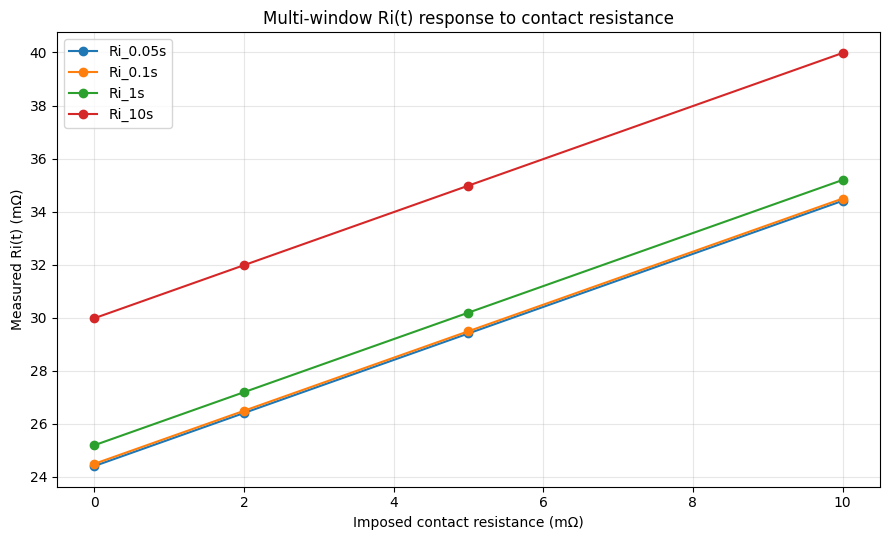

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/resistance_growth_multi_window_Ri.png


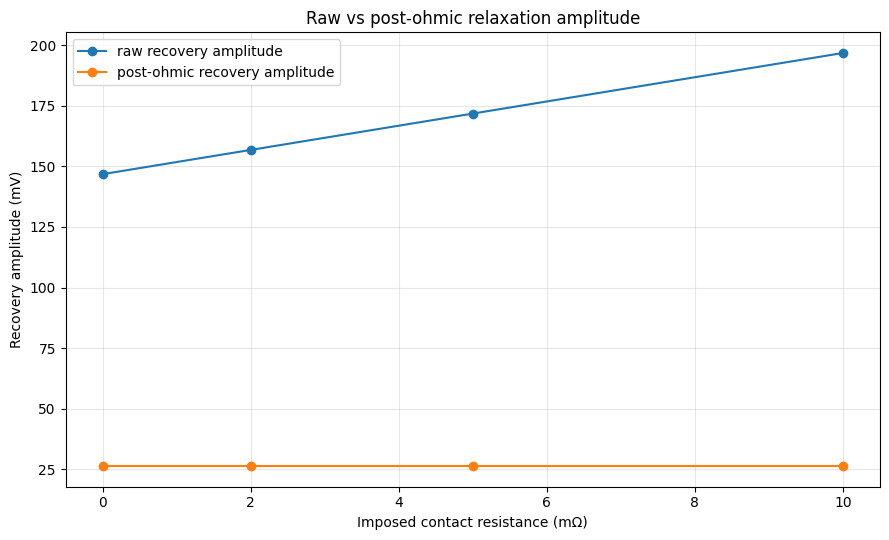

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/resistance_growth_raw_vs_corrected_relaxation.png


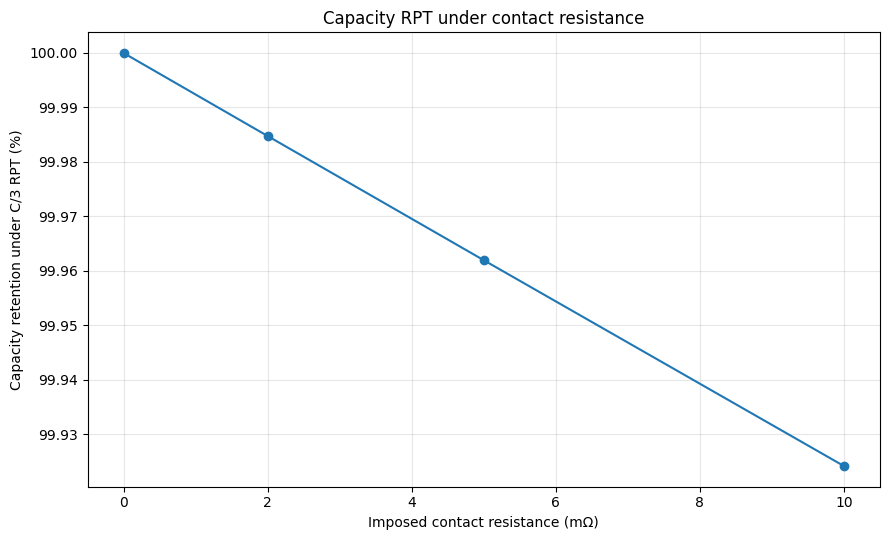

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/resistance_growth_capacity_retention.png
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/resistance_growth_fingerprint_summary_v0_2.csv


,mechanism,capacity_RPT,Ri_0.05s,Ri_0.1s,Ri_1s,Ri_10s,Ri_recovery_0.1s,Ri_recovery_1s,tau_FG_eff,t95,t99,tau_tail,recovery_amplitude,recovery_area,C25_central_VQ,GITT_finite_rest,ICA_DVA_central,endpoint_boundary,best_fitting_targets,rejection_flags
0,contact_ohmic_resistance_growth,weak usable-capacity effect; 10 mΩ capacity lo...,strong additive increase ≈ imposed R_contact,strong additive increase ≈ imposed R_contact,strong additive increase ≈ imposed R_contact,strong additive increase ≈ imposed R_contact,strong additive increase ≈ imposed R_contact,strong additive increase ≈ imposed R_contact,post-ohmic relaxation invariant,post-ohmic relaxation invariant,post-ohmic relaxation invariant,post-ohmic relaxation invariant,raw amplitude increases due to ohmic jump; cor...,raw area increases due to ohmic jump; correcte...,not audited in this notebook,not audited in this notebook,not audited in this notebook,capacity cutoff may show weak usable-capacity ...,"Ri_0.05s, Ri_0.1s, Ri_1s, Ri_10s, Ri_recovery_...",raw recovery amplitude rejected as primary rel...


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/resistance_growth_classification_table.csv


,metric_layer,evidence,strength,classification
0,Ri_additive_response,Maximum additive error across Ri windows = 1.1...,strong,multi-window Ri(t) is the primary contact-resi...
1,corrected_relaxation,Maximum range across corrected relaxation desc...,strong,post-ohmic relaxation dynamics are invariant u...
2,raw_recovery_amplitude,Raw recovery amplitude increases exactly with ...,critical boundary,raw recovery amplitude is ohmic-jump confounde...
3,capacity_RPT,"At 10 mΩ, capacity loss = 0.003828 Ah (0.0758 %).",weak / boundary-level,capacity RPT shows only weak usable-capacity e...
4,overall,Controlled contact resistance produces Ri-domi...,supported,pure ohmic/contact resistance growth is separa...


In [13]:
# Cell 9 — Resistance-growth fingerprint classification and figures
# （阻抗增长指纹分类与图像）

# Figure 1 — multi-window Ri(t)
plt.figure(figsize=(9, 5.5))
for col in ["Ri_0.05s_mOhm", "Ri_0.1s_mOhm", "Ri_1s_mOhm", "Ri_10s_mOhm"]:
    plt.plot(
        hppc_descriptor_table["R_contact_mOhm"],
        hppc_descriptor_table[col],
        marker="o",
        label=col.replace("_mOhm", "")
    )
plt.xlabel("Imposed contact resistance (mΩ)")
plt.ylabel("Measured Ri(t) (mΩ)")
plt.title("Multi-window Ri(t) response to contact resistance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "resistance_growth_multi_window_Ri.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 2 — raw vs corrected relaxation amplitude
plt.figure(figsize=(9, 5.5))
plt.plot(
    relax_comparison["R_contact_mOhm"],
    relax_comparison["recovery_amplitude_mV"],
    marker="o",
    label="raw recovery amplitude"
)
plt.plot(
    relax_comparison["R_contact_mOhm"],
    relax_comparison["post_ohmic_recovery_amplitude_mV"],
    marker="o",
    label="post-ohmic recovery amplitude"
)
plt.xlabel("Imposed contact resistance (mΩ)")
plt.ylabel("Recovery amplitude (mV)")
plt.title("Raw vs post-ohmic relaxation amplitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "resistance_growth_raw_vs_corrected_relaxation.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 3 — capacity RPT
plt.figure(figsize=(9, 5.5))
plt.plot(
    resistance_capacity_rpt_table["R_contact_mOhm"],
    resistance_capacity_rpt_table["capacity_retention_pct"],
    marker="o"
)
plt.xlabel("Imposed contact resistance (mΩ)")
plt.ylabel("Capacity retention under C/3 RPT (%)")
plt.title("Capacity RPT under contact resistance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
p = FIGURES / "resistance_growth_capacity_retention.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Core quantitative signals
ri_error_max = float(ri_additive_error_summary["max_abs_additive_error_mOhm"].max())

corrected_relax_range_max = float(
    corrected_relaxation_invariance_audit["range"].max()
)

capacity_loss_10mOhm = float(
    resistance_capacity_rpt_table.loc[
        resistance_capacity_rpt_table["R_contact_mOhm"] == 10,
        "capacity_loss_Ah_vs_0"
    ].iloc[0]
)

capacity_loss_pct_10mOhm = float(
    resistance_capacity_rpt_table.loc[
        resistance_capacity_rpt_table["R_contact_mOhm"] == 10,
        "capacity_loss_pct_vs_0"
    ].iloc[0]
)

# Fingerprint registry output row for mechanism-comparison synthesis
fingerprint_summary = pd.DataFrame([
    {
        "mechanism": "contact_ohmic_resistance_growth",
        "capacity_RPT": (
            f"weak usable-capacity effect; 10 mΩ capacity loss = "
            f"{capacity_loss_10mOhm:.6f} Ah ({capacity_loss_pct_10mOhm:.4f} %)"
        ),
        "Ri_0.05s": "strong additive increase ≈ imposed R_contact",
        "Ri_0.1s": "strong additive increase ≈ imposed R_contact",
        "Ri_1s": "strong additive increase ≈ imposed R_contact",
        "Ri_10s": "strong additive increase ≈ imposed R_contact",
        "Ri_recovery_0.1s": "strong additive increase ≈ imposed R_contact",
        "Ri_recovery_1s": "strong additive increase ≈ imposed R_contact",
        "tau_FG_eff": "post-ohmic relaxation invariant",
        "t95": "post-ohmic relaxation invariant",
        "t99": "post-ohmic relaxation invariant",
        "tau_tail": "post-ohmic relaxation invariant",
        "recovery_amplitude": "raw amplitude increases due to ohmic jump; corrected amplitude invariant",
        "recovery_area": "raw area increases due to ohmic jump; corrected area invariant",
        "C25_central_VQ": "not audited in this notebook",
        "GITT_finite_rest": "not audited in this notebook",
        "ICA_DVA_central": "not audited in this notebook",
        "endpoint_boundary": "capacity cutoff may show weak usable-capacity shift",
        "best_fitting_targets": "Ri_0.05s, Ri_0.1s, Ri_1s, Ri_10s, Ri_recovery_0.1s",
        "rejection_flags": (
            "raw recovery amplitude rejected as primary relaxation evidence because it is "
            "ohmic-jump confounded"
        ),
    }
])

fingerprint_summary_path = DATA / "resistance_growth_fingerprint_summary_v0_2.csv"
fingerprint_summary.to_csv(fingerprint_summary_path, index=False)

print(f"[OK] saved: {fingerprint_summary_path}")
display(fingerprint_summary)

classification_table = pd.DataFrame([
    {
        "metric_layer": "Ri_additive_response",
        "evidence": f"Maximum additive error across Ri windows = {ri_error_max:.6e} mΩ.",
        "strength": "strong",
        "classification": "multi-window Ri(t) is the primary contact-resistance fingerprint",
    },
    {
        "metric_layer": "corrected_relaxation",
        "evidence": f"Maximum range across corrected relaxation descriptors = {corrected_relax_range_max:.6e}.",
        "strength": "strong",
        "classification": "post-ohmic relaxation dynamics are invariant under contact resistance",
    },
    {
        "metric_layer": "raw_recovery_amplitude",
        "evidence": "Raw recovery amplitude increases exactly with I·R_contact contribution.",
        "strength": "critical boundary",
        "classification": "raw recovery amplitude is ohmic-jump confounded and must not be used as primary relaxation evidence",
    },
    {
        "metric_layer": "capacity_RPT",
        "evidence": (
            f"At 10 mΩ, capacity loss = {capacity_loss_10mOhm:.6f} Ah "
            f"({capacity_loss_pct_10mOhm:.4f} %)."
        ),
        "strength": "weak / boundary-level",
        "classification": "capacity RPT shows only weak usable-capacity effect under pure contact resistance",
    },
    {
        "metric_layer": "overall",
        "evidence": "Controlled contact resistance produces Ri-dominant fingerprint with invariant post-ohmic relaxation.",
        "strength": "supported",
        "classification": "pure ohmic/contact resistance growth is separable from SEI-only capacity-dominant aging",
    },
])

classification_path = DATA / "resistance_growth_classification_table.csv"
classification_table.to_csv(classification_path, index=False)

print(f"[OK] saved: {classification_path}")
display(classification_table)

In [14]:
# Cell 10 — Notebook 23 output inventory audit（Notebook 23 输出文件清单审计）

expected_outputs = [
    DATA / "mechanism_fingerprint_registry_v0_2.csv",
    DATA / "resistance_growth_hppc_segment_audit.csv",
    DATA / "resistance_growth_capacity_segment_audit.csv",
    DATA / "resistance_growth_hppc_descriptor_table.csv",
    DATA / "resistance_growth_corrected_relaxation_descriptor_table.csv",
    DATA / "resistance_growth_raw_vs_corrected_relaxation_audit.csv",
    DATA / "resistance_growth_ri_additive_audit.csv",
    DATA / "resistance_growth_ri_additive_error_summary.csv",
    DATA / "resistance_growth_corrected_relaxation_invariance_audit.csv",
    DATA / "resistance_growth_capacity_selected_segment_audit.csv",
    DATA / "resistance_growth_capacity_rpt_table.csv",
    DATA / "resistance_growth_fingerprint_summary_v0_2.csv",
    DATA / "resistance_growth_classification_table.csv",
    FIGURES / "resistance_growth_multi_window_Ri.png",
    FIGURES / "resistance_growth_raw_vs_corrected_relaxation.png",
    FIGURES / "resistance_growth_capacity_retention.png",
]

inventory_rows = []

for p in expected_outputs:
    inventory_rows.append({
        "path": str(p.relative_to(REPO)),
        "exists": p.exists(),
        "size_kB": round(p.stat().st_size / 1024, 2) if p.exists() else np.nan,
    })

output_inventory = pd.DataFrame(inventory_rows)

inventory_path = DATA / "resistance_growth_output_inventory.csv"
output_inventory.to_csv(inventory_path, index=False)

print(f"[OK] saved: {inventory_path}")
display(output_inventory)

assert output_inventory["exists"].all(), "Some expected Notebook 23 output files are missing."
print("[OK] All expected Notebook 23 outputs exist.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/resistance_growth_output_inventory.csv


,path,exists,size_kB
0,data/mechanism_fingerprint_registry_v0_2.csv,True,2.71
1,data/resistance_growth_hppc_segment_audit.csv,True,2.54
2,data/resistance_growth_capacity_segment_audit.csv,True,1.49
3,data/resistance_growth_hppc_descriptor_table.csv,True,2.44
4,data/resistance_growth_corrected_relaxation_de...,True,0.84
5,data/resistance_growth_raw_vs_corrected_relaxa...,True,1.33
6,data/resistance_growth_ri_additive_audit.csv,True,1.27
7,data/resistance_growth_ri_additive_error_summa...,True,0.67
8,data/resistance_growth_corrected_relaxation_in...,True,0.74
9,data/resistance_growth_capacity_selected_segme...,True,1.22


[OK] All expected Notebook 23 outputs exist.


## Final closure — Notebook 23

### Key findings

Notebook 23 audited whether pure ohmic/contact resistance growth produces a diagnostic fingerprint that can be separated from the SEI-only aging branch established in Notebooks 15–22.

The mechanism branch was implemented as a controlled contact-resistance perturbation, not as a full electrochemical aging simulation.

Contact resistance levels:

- 0 mΩ,
- 2 mΩ,
- 5 mΩ,
- 10 mΩ.

The diagnostic design included:

1. HPPC-like pulse branch at approximately 50% SOC,
2. C/3 capacity RPT branch,
3. multi-window Ri(t) extraction,
4. recovery-side Ri extraction,
5. raw and post-ohmic relaxation descriptor separation,
6. Mechanism Fingerprint Registry v0.2 output.

### Mechanism Fingerprint Registry v0.2

Notebook 23 froze the following registry structure for all future mechanism-contrast notebooks:

- `capacity_RPT`
- `Ri_0.05s`
- `Ri_0.1s`
- `Ri_1s`
- `Ri_10s`
- `Ri_recovery_0.1s`
- `Ri_recovery_1s`
- `tau_FG_eff`
- `t95`
- `t99`
- `tau_tail`
- `recovery_amplitude`
- `recovery_area`
- `C25_central_VQ`
- `GITT_finite_rest`
- `ICA_DVA_central`
- `endpoint_boundary`
- `best_fitting_targets`
- `rejection_flags`

This registry will be reused for the later resistance, LAM, plating, and cross-mechanism synthesis notebooks.

### SOC condition of the Ri(t) audit

The HPPC-like Ri(t) branch was performed at approximately mid-SOC.

Protocol:

- initial SOC = 1.0,
- C/3 discharge for 90 min,
- 60 min rest,
- 1C discharge pulse for 10 s,
- 600 s relaxation.

Because the OKane2022 cell capacity in this branch is approximately 5.05 Ah, the 90 min C/3 pre-discharge removes approximately 2.50 Ah. Therefore, the 1C pulse is applied at approximately:

`SOC ≈ 1 − 2.50 / 5.05 ≈ 50.5%`

This notebook is therefore a single-SOC mechanism-isolation audit, not a full SOC-resolved Ri map.

### Ri(t) / multi-window resistance fingerprint

The imposed contact resistance was recovered almost exactly as an additive shift in every Ri(t) window.

For example, `Ri_0.05s` increased as:

- 0 mΩ contact resistance: 24.4075 mΩ,
- 2 mΩ contact resistance: 26.4075 mΩ,
- 5 mΩ contact resistance: 29.4075 mΩ,
- 10 mΩ contact resistance: 34.4075 mΩ.

The same additive behavior was observed for:

- `Ri_0.05s`,
- `Ri_0.1s`,
- `Ri_1s`,
- `Ri_10s`,
- `Ri_recovery_0.1s`,
- `Ri_recovery_1s`.

The maximum additive error across Ri windows was approximately `1.18e-10 mΩ`, effectively numerical zero.

This establishes a clean contact-resistance fingerprint:

`multi-window Ri(t) = baseline Ri(t) + imposed R_contact`

### Raw recovery amplitude versus corrected post-ohmic relaxation

The raw recovery amplitude increased with contact resistance:

- 0 mΩ: 146.78 mV,
- 2 mΩ: 156.78 mV,
- 5 mΩ: 171.78 mV,
- 10 mΩ: 196.78 mV.

This increase corresponds directly to the instantaneous ohmic jump:

`ΔU = I_pulse · R_contact`

Because the pulse current is approximately 5 A:

- 2 mΩ corresponds to approximately 10 mV,
- 5 mΩ corresponds to approximately 25 mV,
- 10 mΩ corresponds to approximately 50 mV.

Therefore, raw recovery amplitude is not a pure relaxation descriptor. It is a mixed observable:

`raw recovery = instantaneous ohmic jump + post-ohmic relaxation`

After removing the immediate current-off jump by starting the relaxation analysis at `t_off + 0.1 s`, the corrected post-ohmic relaxation descriptors were invariant across contact-resistance levels:

- post-ohmic recovery amplitude: 26.3136 mV,
- post-ohmic `tau_FG_eff`: 25.5 s,
- post-ohmic `t95`: 171.1 s,
- post-ohmic `t99`: 409.1 s,
- post-ohmic `tau_tail`: 72.077 s.

This shows that pure contact resistance changes the instantaneous voltage response but does not materially change post-ohmic relaxation dynamics.

### Capacity RPT response

The C/3 capacity RPT showed only a weak usable-capacity boundary effect.

Capacity retention under 10 mΩ contact resistance was approximately:

`99.9242%`

The corresponding apparent capacity loss was:

- `0.003828 Ah`,
- `0.0758%`.

This is much smaller than the capacity fade observed in the stronger SEI-only branch. Therefore, contact resistance does not produce a capacity-dominant fingerprint. The observed capacity change is best interpreted as a voltage-cutoff / usable-capacity effect under the 2.5 V terminal-voltage boundary, not as true lithium inventory loss.

### Integrated interpretation

Notebook 23 establishes a clean contrast against the SEI-only branch.

SEI-only aging from Notebooks 20–22 is best described as:

`capacity-dominant, voltage-secondary, derivative-auxiliary`

Pure contact / ohmic resistance growth is best described as:

`Ri(t)-dominant, post-ohmic-relaxation-invariant, capacity-weak`

This separation is important for Porsche-style aging-model parameterization because it shows that different mechanisms require different primary fitting targets.

For contact resistance growth, the recommended primary fitting targets are:

- `Ri_0.05s`,
- `Ri_0.1s`,
- `Ri_1s`,
- `Ri_10s`,
- `Ri_recovery_0.1s`,
- `Ri_recovery_1s`.

The following should not be used as primary relaxation evidence:

- raw recovery amplitude,
- raw recovery area,
- raw `t95` / `t99` without post-ohmic correction.

These raw recovery descriptors are confounded by the instantaneous ohmic jump.

### Correct conclusion wording

Supported:

- Contact resistance produces a nearly exact additive increase in all Ri(t) windows.
- Multi-window Ri(t) is the primary fingerprint of contact / ohmic resistance growth.
- Recovery-side Ri also captures the imposed contact resistance.
- Corrected post-ohmic relaxation descriptors are invariant across contact resistance.
- Pure contact resistance is separable from SEI-only aging.
- Capacity RPT shows only a weak usable-capacity boundary effect under contact resistance.

Not supported:

- Raw recovery amplitude should not be interpreted as slow relaxation growth.
- Raw recovery-area increase should not be interpreted as increased diffusion or polarization without post-ohmic correction.
- Contact resistance does not produce a capacity-dominant aging fingerprint.
- This notebook does not establish SOC-resolved resistance-growth behavior.
- This notebook does not evaluate C/25 V(Q), GITT-like finite-rest, or ICA/DVA under contact resistance.

### Project-level classification

`contact / ohmic resistance growth = Ri(t)-dominant fingerprint`

Project-level wording:

> Pure contact resistance growth produces a clean, window-invariant additive increase in pulse-based Ri(t), while corrected post-ohmic relaxation dynamics remain unchanged. Capacity RPT shows only a weak voltage-boundary effect. This mechanism is therefore separable from SEI-only aging and should be parameterized primarily using multi-window pulse resistance targets rather than capacity or derivative-voltage features.

### Next step

The next mechanism branch should be:

`24_LAM_fingerprint_audit.ipynb`

The purpose is to test whether loss of active material produces a voltage-shape and derivative-feature fingerprint that is stronger than SEI-only aging and fundamentally different from contact resistance growth.

Expected LAM-sensitive layers:

- capacity RPT,
- C/25 central-window V(Q),
- GITT-like finite-rest voltage points,
- ICA/DVA central features,
- endpoint / usable-capacity boundary behavior.

The same Mechanism Fingerprint Registry v0.2 should be reused so that SEI, resistance growth, LAM, and plating can later be compared in a unified cross-mechanism synthesis notebook.